In [71]:
from langgraph.graph import START,END,StateGraph
from typing import TypedDict,Literal

In [72]:
from pydantic import BaseModel, Field

In [73]:
from dotenv import load_dotenv

In [74]:
from langchain_ollama import ChatOllama
from langchain_google_genai import ChatGoogleGenerativeAI

In [75]:
class ArticleState(TypedDict):
    topic: str
    article: str
    article_result: Literal['approved','needs_improvement']
    iteration:int
    max_iteration: int
    feedback: str

In [76]:
class EvatuatorSchema(BaseModel):
    decision: Literal['approved','needs_improvement'] = Field(description="Approve or suggest improvements in article")
    feedback: str = Field(description="Feedback on Article Improvement")

In [77]:
load_dotenv()

True

In [78]:
llm = ChatOllama(model='qwen3:8b')
llm2 = ChatGoogleGenerativeAI(model = 'gemini-flash-lite-latest')

In [79]:
llm2.invoke("in 1 word,answer how are you?")

AIMessage(content=[{'type': 'text', 'text': 'Functional.', 'extras': {'signature': 'EjQKMgERTTIPAeDAiw88wKjN89BubZcv9MEuOKuwhkZLDLORuTPXFo/QzpYTATQK6pA8eu85'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f757f-70f5-78b0-ab95-7a84816561b9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 2, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [80]:
graph = StateGraph(ArticleState)

In [81]:
def article_generator(state: ArticleState):
    topic = state['topic']

    prompt = f"generate a 300 word article on the topic: {topic}"

    response = llm.invoke(prompt).content
    
    return ({'article':response,})

In [82]:
def article_evaluator(state: ArticleState):
    topic = state['topic']
    article = state['article']

    prompt = f"Evaluate the article basis the in depth analysis and suggest necessary improvements. Article:{article}. \n Topic: {topic}. "
    
    evaluator_llm = llm2.with_structured_output(EvatuatorSchema)
    response = evaluator_llm.invoke(prompt)

    iteration = state['iteration']+1

    print("State: ", state)
    
    return ({'article_result':response.decision,'feedback':response.feedback,'iteration':iteration})

In [83]:
def article_optimizer(state: ArticleState):
    topic = state['topic']
    article = state['article']
    feedback = state['feedback']
    iteration = state['iteration']

    prompt = f"Optimize the article basis the feedback.\n Feedback:{feedback} \n Article:{article}. \n Topic: {topic}. "
    
    response = llm.invoke(prompt).content
    # response = evaluator_llm.invoke(prompt)

    
    return ({'article':response})

In [84]:
def router(state: ArticleState):
    decision = state['article_result']
    iteration = state['iteration']
    max_iteration = state['max_iteration']

    if(decision=='approved' or iteration>=max_iteration):
        return 'approved'
    else:
        return 'needs_improvement'

In [85]:
graph.add_node('article_generator',article_generator)
graph.add_node('article_evaluator',article_evaluator)
graph.add_node('article_optimizer',article_optimizer)

In [86]:
graph.add_edge(START,'article_generator')
graph.add_edge('article_generator','article_evaluator')
graph.add_conditional_edges('article_evaluator',router,{'approved':END,'needs_improvement':'article_optimizer'})
graph.add_edge('article_optimizer','article_evaluator')

In [87]:
workflow = graph.compile()

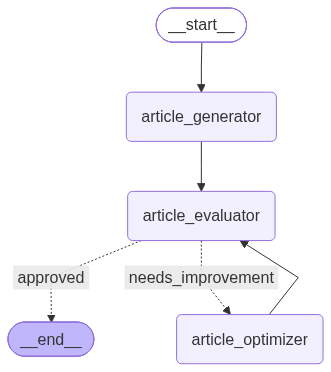

In [88]:
workflow

In [89]:
initial_state = {'topic':'Ethanol blending in petrol in india 2026','max_iteration':5,'iteration':0}

In [90]:
workflow.invoke(initial_state)

State:  {'topic': 'Ethanol blending in petrol in india 2026', 'article': '**Ethanol Blending in Petrol in India by 2026: A Step Toward Sustainable Energy**  \n\nIndia’s push for ethanol blending in petrol is a pivotal initiative aimed at reducing fossil fuel dependence, cutting emissions, and bolstering the agricultural sector. The government has set an ambitious target of achieving 20% ethanol blending in petrol (E20) by 2026, a goal underpinned by the National Biofuel Policy (2018) and the Ethanol Blending Programme (EBP). This target is part of India’s broader strategy to transition toward cleaner energy and meet its climate commitments under the Paris Agreement.  \n\nEthanol, a renewable fuel derived from crops like sugarcane and maize, offers multiple benefits. It reduces greenhouse gas emissions compared to conventional petrol, curbs air pollution, and provides a domestic alternative to imported crude oil, thereby enhancing energy security. By 2023, ethanol blending in India had 

{'topic': 'Ethanol blending in petrol in india 2026',
 'article': "**Ethanol Blending in Petrol in India by 2026: A Step Toward Sustainable Energy**  \n\nIndia’s push for ethanol blending in petrol is a pivotal initiative aimed at reducing fossil fuel dependence, cutting emissions, and bolstering the agricultural sector. The government has set an ambitious target of achieving **20% ethanol blending in petrol (E20)** by 2026, a goal underpinned by the National Biofuel Policy (2018) and the Ethanol Blending Programme (EBP). This target is part of India’s broader strategy to transition toward cleaner energy and meet its climate commitments under the Paris Agreement.  \n\n### **Current Progress and Targets**  \nAs of 2023, ethanol blending in India has reached approximately **10-12%**, with the government aiming to scale production to meet the 2026 target. Current ethanol production capacity stands at around **4.5 million tons per year**, but this needs to increase to **8-10 million tons a